# Exploratory Data Analysis (EDA) - News Sentiment for Price Prediction

This notebook performs comprehensive exploratory data analysis on the news sentiment dataset to understand:
- Descriptive Statistics
- Text Analysis and Topic Modeling
- Time Series Analysis
- Publisher Analysis

## Table of Contents
1. [Data Loading and Initial Exploration](#data-loading)
2. [Descriptive Statistics](#descriptive-stats)
3. [Text Analysis and Topic Modeling](#text-analysis)
4. [Time Series Analysis](#time-series)
5. [Publisher Analysis](#publisher-analysis)
6. [Key Insights and Conclusions](#conclusions)

In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Text processing libraries
import re
from collections import Counter
try:
    from wordcloud import WordCloud
except ImportError:
    print('WordCloud not available, install with: pip install wordcloud')

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Topic modeling
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.cluster import KMeans

# Time series analysis
from datetime import datetime, timedelta
import calendar

# Set style for plots
plt.style.use('default')
sns.set_palette("husl")

# Download NLTK data
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')

print("Libraries imported successfully!")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


Libraries imported successfully!


## 1. Data Loading and Initial Exploration {#data-loading}

In [7]:
# Load the dataset
df = pd.read_csv('/raw_analyst_ratings.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (171393, 6)

Columns: ['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock']

First few rows:


,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [8]:
# Basic information about the dataset
print("Dataset Info:")
print(df.info())
print("\n" + "="*50)
print("Missing Values:")
print(df.isnull().sum())
print("\n" + "="*50)
print("Data Types:")
print(df.dtypes)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 171393 entries, 0 to 171392
Data columns (total 6 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Unnamed: 0  171393 non-null  int64 
 1   headline    171393 non-null  object
 2   url         171393 non-null  object
 3   publisher   171393 non-null  object
 4   date        171393 non-null  object
 5   stock       171392 non-null  object
dtypes: int64(1), object(5)
memory usage: 7.8+ MB
None

Missing Values:
Unnamed: 0    0
headline      0
url           0
publisher     0
date          0
stock         1
dtype: int64

Data Types:
Unnamed: 0     int64
headline      object
url           object
publisher     object
date          object
stock         object
dtype: object


In [10]:
# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'], format='mixed', errors='coerce')

# Add a check to see if the conversion was successful
if df['date'].dtype != 'datetime64[ns]':
    print("Warning: Date column could not be fully converted to datetime. Checking for NaT values.")
    # You might want to inspect the original values that caused the conversion failure
    # print(df[df['date'].isna()]['date_original_column'].head()) # If you kept the original column

# Extract additional time features
# Ensure that you are only performing these operations if the date column is datetime-like
if pd.api.types.is_datetime64_any_dtype(df['date']):
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['day'] = df['date'].dt.day
    df['weekday'] = df['date'].dt.dayofweek
    df['hour'] = df['date'].dt.hour
    df['weekday_name'] = df['date'].dt.day_name()
    df['month_name'] = df['date'].dt.month_name()
else:
    print("Error: Date column is not of datetime type after conversion. Cannot extract time features.")
    # You might want to stop execution or handle this case appropriately
    # For example, you could drop rows with NaT dates:
    # df.dropna(subset=['date'], inplace=True)


# Calculate headline length
df['headline_length'] = df['headline'].str.len()
df['headline_word_count'] = df['headline'].str.split().str.len()

print("Date processing completed!")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Total records with valid dates: {df['date'].notna().sum():,}")

Date processing completed!
Date range: 2020-05-22 08:06:17-04:00 to 2020-06-05 10:30:54-04:00
Total records with valid dates: 39


## 2. Descriptive Statistics {#descriptive-stats}

In [11]:
# Basic statistics for headline lengths
print("HEADLINE LENGTH STATISTICS")
print("="*40)
print(df['headline_length'].describe())
print("\nHEADLINE WORD COUNT STATISTICS")
print("="*40)
print(df['headline_word_count'].describe())

HEADLINE LENGTH STATISTICS
count    171393.000000
mean         73.285228
std          40.251316
min           5.000000
25%          47.000000
50%          65.000000
75%          87.000000
max         458.000000
Name: headline_length, dtype: float64

HEADLINE WORD COUNT STATISTICS
count    171393.000000
mean         11.372880
std           6.145001
min           1.000000
25%           7.000000
50%          10.000000
75%          14.000000
max          70.000000
Name: headline_word_count, dtype: float64


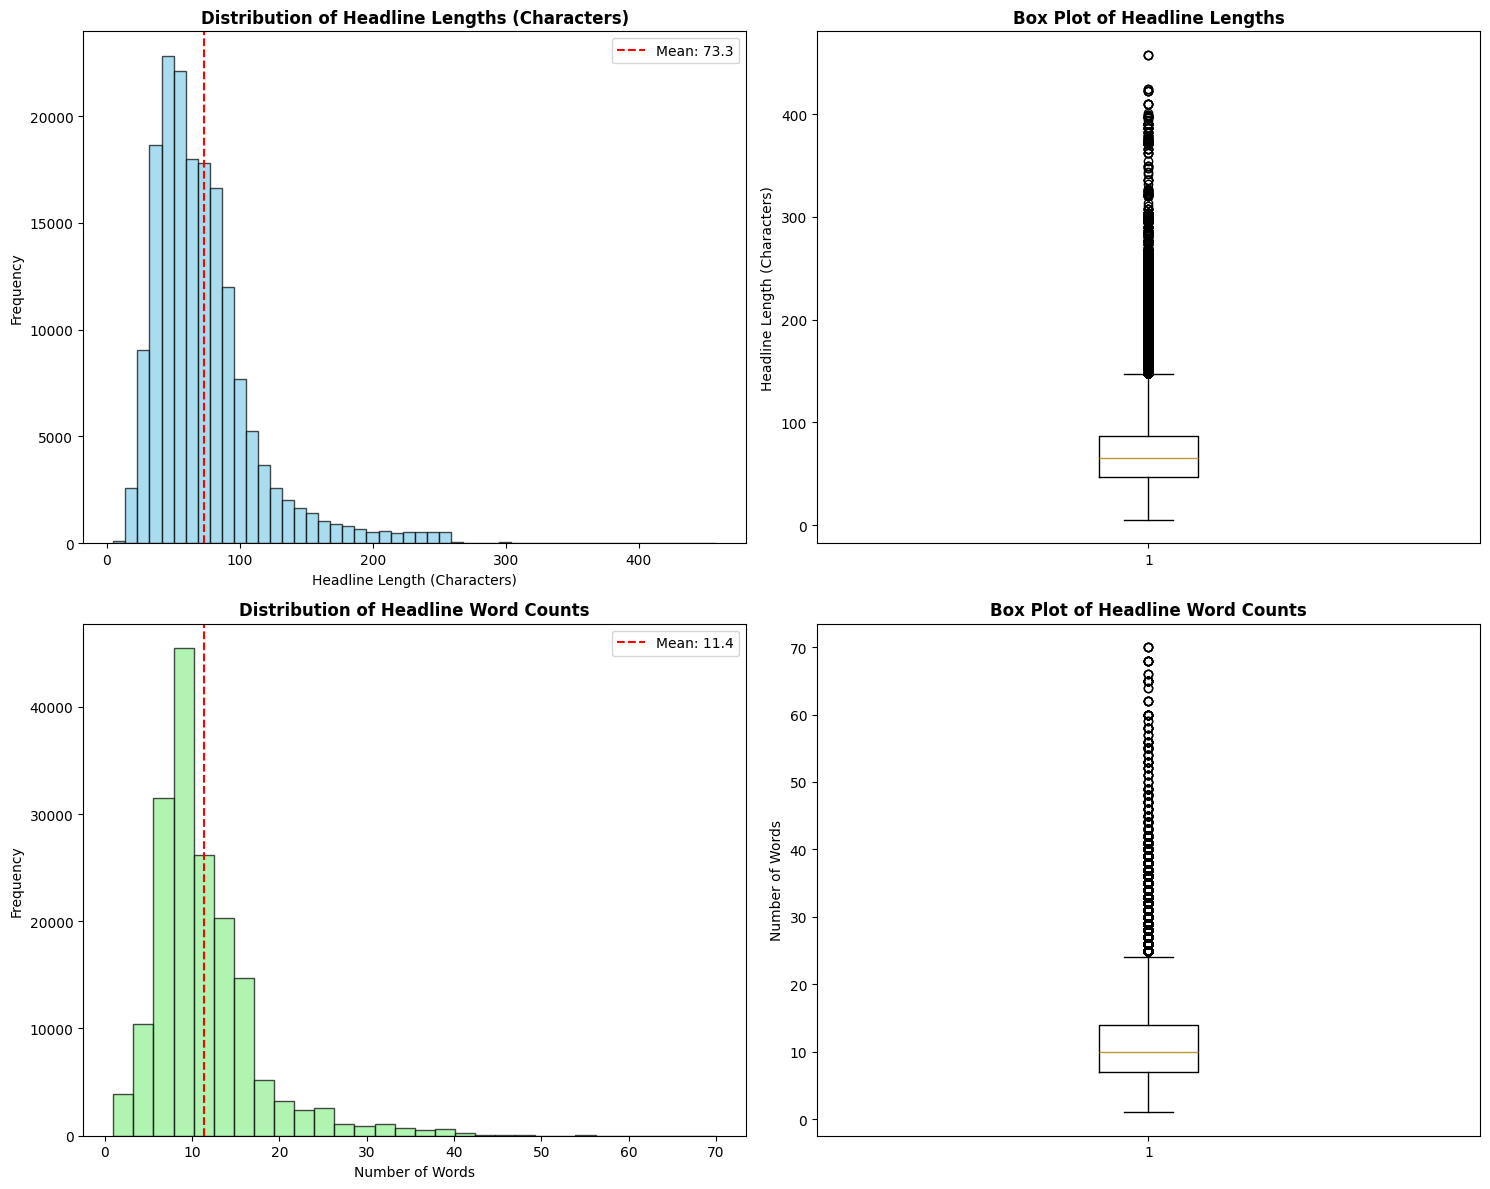

In [12]:
# Visualization of headline lengths
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Histogram of headline lengths
axes[0, 0].hist(df['headline_length'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Distribution of Headline Lengths (Characters)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Headline Length (Characters)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(df['headline_length'].mean(), color='red', linestyle='--', label=f'Mean: {df["headline_length"].mean():.1f}')
axes[0, 0].legend()

# Box plot of headline lengths
axes[0, 1].boxplot(df['headline_length'])
axes[0, 1].set_title('Box Plot of Headline Lengths', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Headline Length (Characters)')

# Histogram of word counts
axes[1, 0].hist(df['headline_word_count'], bins=30, alpha=0.7, color='lightgreen', edgecolor='black')
axes[1, 0].set_title('Distribution of Headline Word Counts', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Number of Words')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].axvline(df['headline_word_count'].mean(), color='red', linestyle='--', label=f'Mean: {df["headline_word_count"].mean():.1f}')
axes[1, 0].legend()

# Box plot of word counts
axes[1, 1].boxplot(df['headline_word_count'])
axes[1, 1].set_title('Box Plot of Headline Word Counts', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Number of Words')

plt.tight_layout()
plt.show()

TOP 20 MOST ACTIVE PUBLISHERS
publisher
Paul Quintaro        28232
Lisa Levin           24200
Benzinga Newsdesk    18476
Charles Gross        11842
Monica Gerson        10575
Eddie Staley          7063
Hal Lindon            6032
Benzinga Staff        3627
Juan Lopez            3552
Vick Meyer            3382
Zacks                 2919
webmaster             2740
Shanthi Rexaline      2683
Benzinga_Newsdesk     2292
Jayson Derrick        2157
Allie Wickman         1970
ETF Professor         1744
Nelson Hem            1683
Craig Jones           1652
Dwight Einhorn        1582
Name: count, dtype: int64


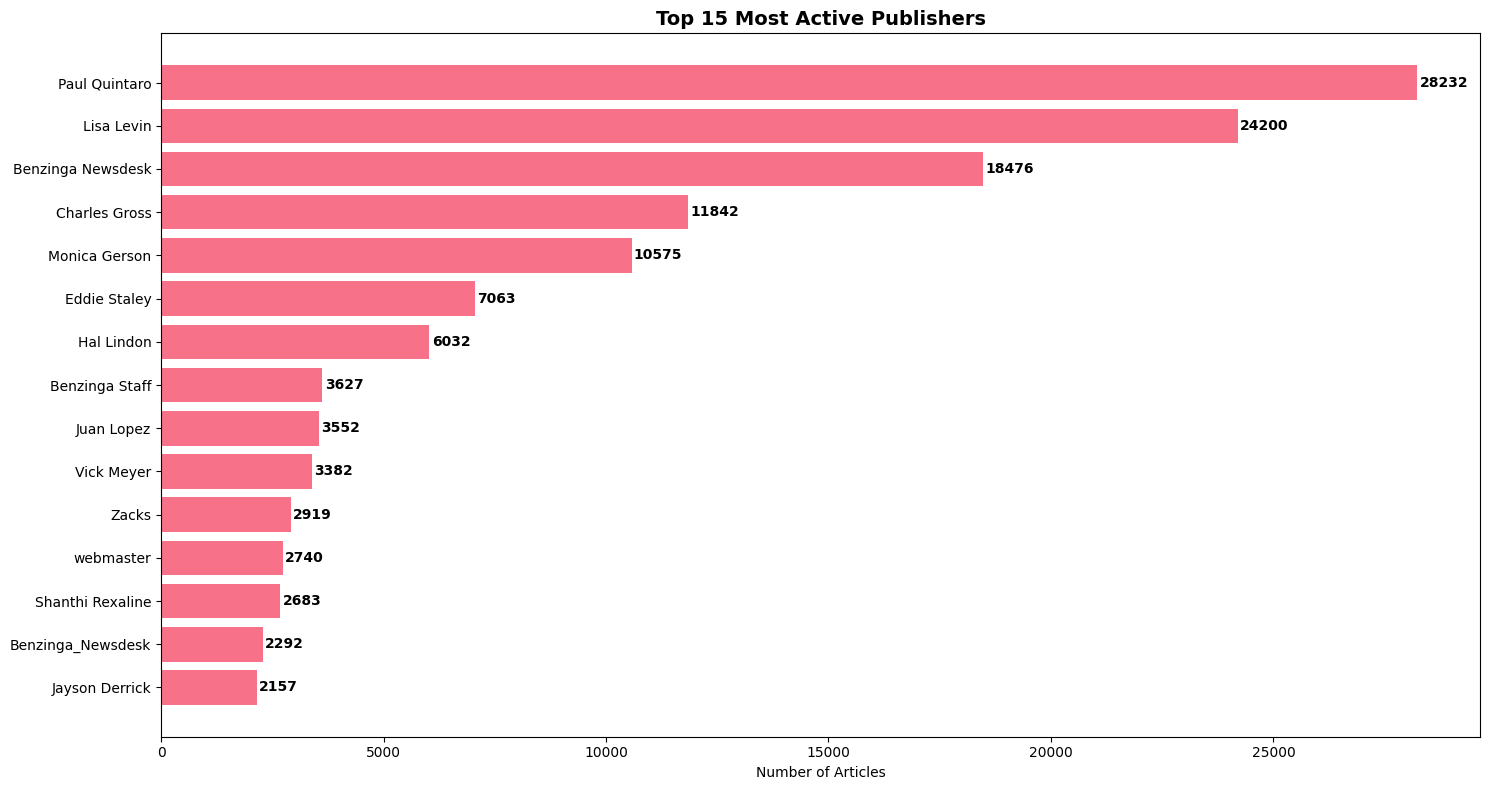

In [13]:
# Articles per publisher
publisher_counts = df['publisher'].value_counts()
print("TOP 20 MOST ACTIVE PUBLISHERS")
print("="*40)
print(publisher_counts.head(20))

# Visualization
plt.figure(figsize=(15, 8))
top_publishers = publisher_counts.head(15)
plt.barh(range(len(top_publishers)), top_publishers.values)
plt.yticks(range(len(top_publishers)), top_publishers.index)
plt.xlabel('Number of Articles')
plt.title('Top 15 Most Active Publishers', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

# Add value labels on bars
for i, v in enumerate(top_publishers.values):
    plt.text(v + 50, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.show()

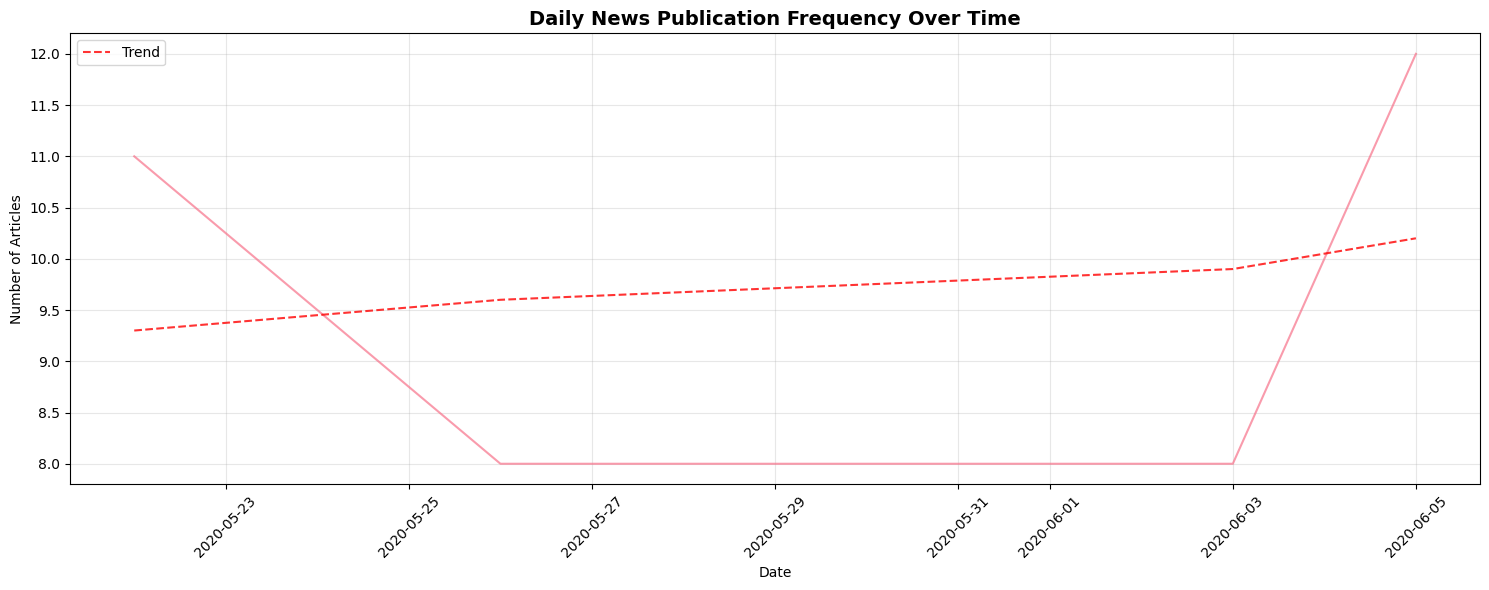

Average daily articles: 9.8
Max daily articles: 12 on 2020-06-05
Min daily articles: 8 on 2020-05-26


In [14]:
# Publication trends over time
# Daily publication counts
daily_counts = df.groupby(df['date'].dt.date).size()

plt.figure(figsize=(15, 6))
plt.plot(daily_counts.index, daily_counts.values, alpha=0.7)
plt.title('Daily News Publication Frequency Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Number of Articles')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Add trend line
z = np.polyfit(range(len(daily_counts)), daily_counts.values, 1)
p = np.poly1d(z)
plt.plot(daily_counts.index, p(range(len(daily_counts))), "r--", alpha=0.8, label='Trend')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Average daily articles: {daily_counts.mean():.1f}")
print(f"Max daily articles: {daily_counts.max()} on {daily_counts.idxmax()}")
print(f"Min daily articles: {daily_counts.min()} on {daily_counts.idxmin()}")

## 3. Text Analysis and Topic Modeling {#text-analysis}

In [5]:
## Text preprocessing function
# Reload the dataset - NOTE: This line was present in the original faulty cell.
# If your workflow processes the dataframe sequentially, you might not need to reload it here.
# If this cell is intended to be run independently, keep the reload.
# df = pd.read_csv('/content/raw_analyst_ratings.csv')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import pandas as pd
import re
import nltk # Ensure nltk is imported for download

# Download necessary NLTK data if not already present
# This needs to be done before using corpus like stopwords or tokenizers
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt', quiet=True)

# Add this download for the specific resource requested by word_tokenize
try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab', quiet=True)

try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords', quiet=True) # Ensure stopwords are downloaded

try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet', quiet=True)


# Initialize once
# Ensure stopwords are downloaded before calling stopwords.words
# The explicit download below is redundant if the try/except above is used,
# but keeping it doesn't hurt.
nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Preprocessing function
def preprocess_text(text):
    if pd.isna(text):
        return ""

    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # The error originated from the word_tokenize line requiring 'punkt_tab'
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(token) for token in tokens if token not in stop_words and len(token) > 2]
    return ' '.join(tokens)

# Apply preprocessing
print("Preprocessing headlines...")
df['headline_processed'] = df['headline'].apply(preprocess_text)
print("Preprocessing completed!")

Preprocessing headlines...
Preprocessing completed!


In [ ]:
# Word frequency analysis
all_words = ' '.join(df['headline_processed']).split()
word_freq = Counter(all_words)

print("TOP 30 MOST COMMON WORDS")
print("="*40)
for word, count in word_freq.most_common(30):
    print(f"{word}: {count}")

TOP 30 MOST COMMON WORDS
stock: 201100
share: 146182
est: 140660
eps: 128929
report: 124503
market: 120900
update: 93394
earnings: 87185
sale: 85320
top: 81280
price: 74211
week: 70774
buy: 68661
lower: 68095
announces: 66529
company: 65424
downgrade: 63812
trading: 61165
raise: 59896
upgrade: 58999
benzingas: 57985
target: 56343
maintains: 52961
etf: 50029
estimate: 49942
higher: 48163
new: 48061
session: 45810
inc: 45115
say: 44275


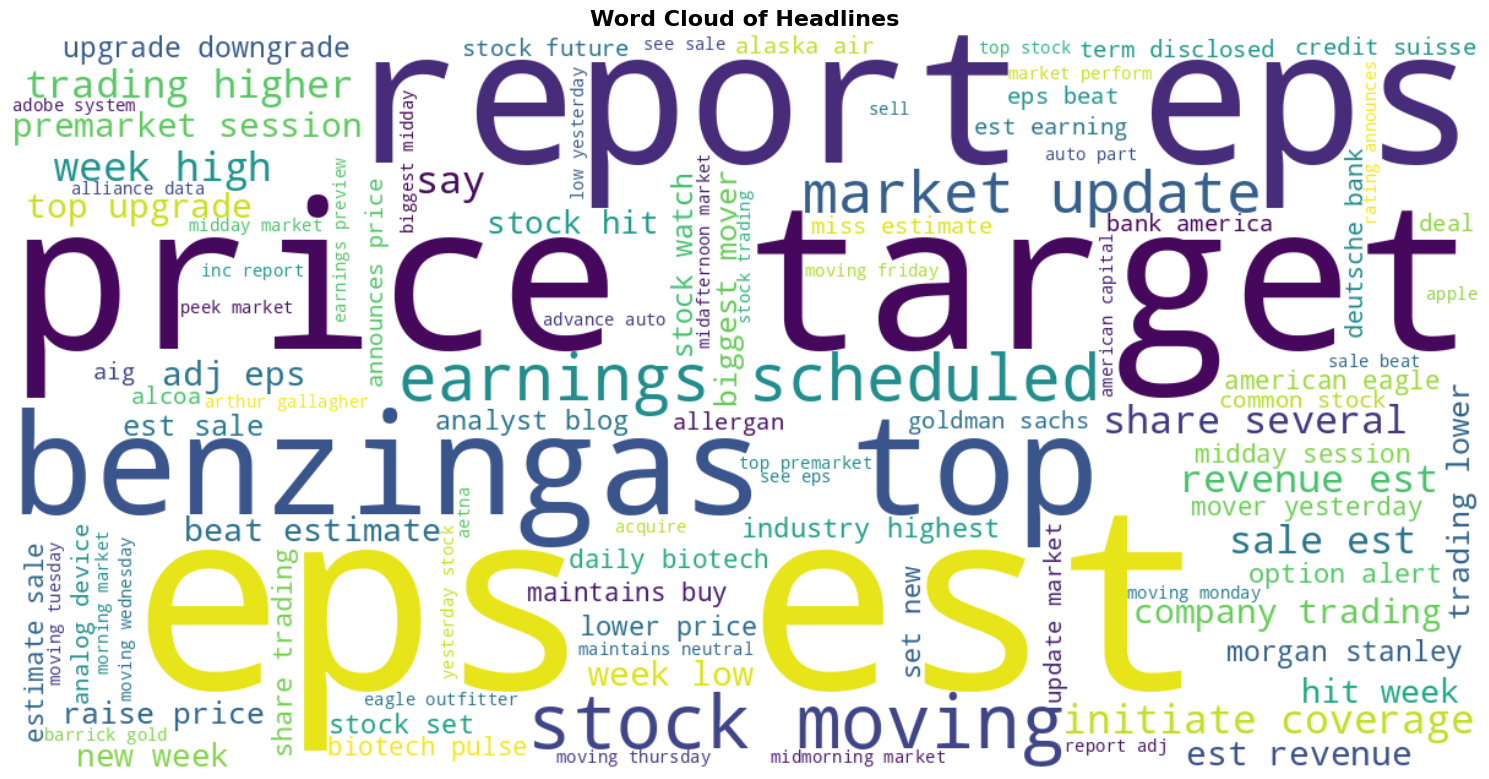

In [7]:
# Word cloud visualization (if available)
# Import matplotlib.pyplot if it's not guaranteed to be imported elsewhere
import matplotlib.pyplot as plt

try:
    from wordcloud import WordCloud
    wordcloud = WordCloud(width=1200, height=600,
                         background_color='white',
                         max_words=100,
                         colormap='viridis').generate(' '.join(df['headline_processed']))

    plt.figure(figsize=(15, 8))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Word Cloud of Headlines', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
except ImportError:
    print("WordCloud not available. Install with: pip install wordcloud")
    # Create a simple bar chart instead
    top_words = word_freq.most_common(20)
    words, counts = zip(*top_words)

    plt.figure(figsize=(12, 8))
    plt.barh(words, counts)
    plt.xlabel('Frequency')
    plt.title('Top 20 Most Common Words in Headlines', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

FINANCIAL KEYWORDS FREQUENCY
earnings: 4206
downgrade: 3272
upgrade: 3095
price target: 2648
revenue: 2000
analyst: 1316
rating: 1257
dividend: 1035
guidance: 841
volume: 567
acquisition: 525
profit: 518
loss: 349
ipo: 319
buyback: 311
merger: 282
bull: 270
rally: 195
fda approval: 137
bear: 118
volatility: 98
selloff: 62
recommendation: 27


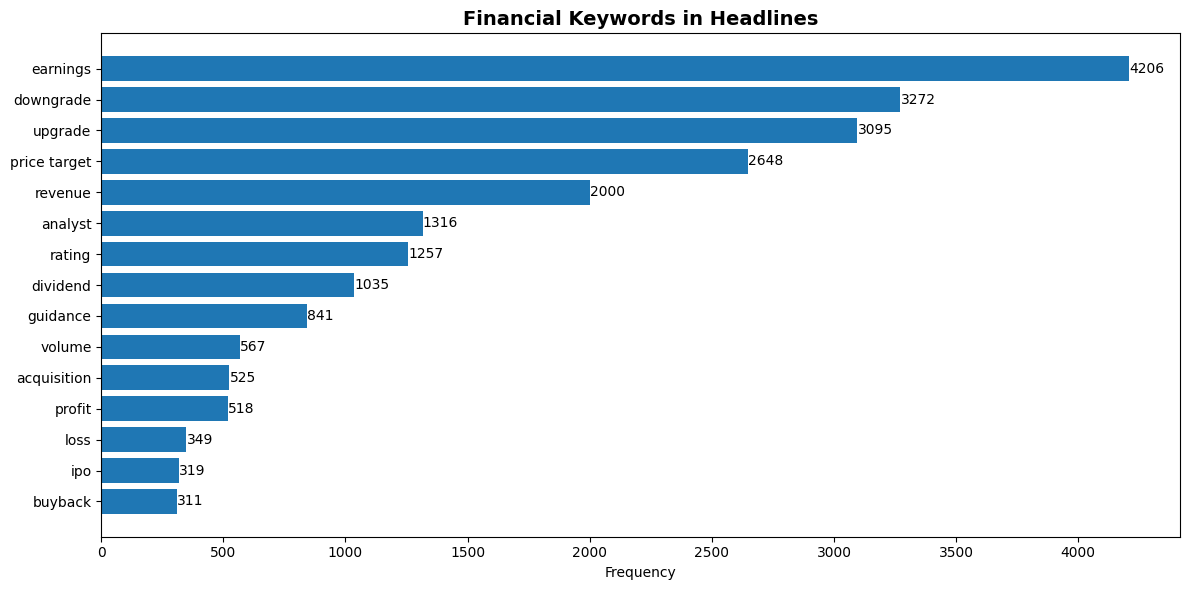

In [8]:
# Financial keywords analysis
financial_keywords = [
    'fda approval', 'price target', 'earnings', 'revenue', 'profit', 'loss',
    'acquisition', 'merger', 'ipo', 'dividend', 'buyback', 'guidance',
    'upgrade', 'downgrade', 'analyst', 'rating', 'recommendation',
    'bull', 'bear', 'rally', 'selloff', 'volatility', 'volume'
]

keyword_counts = {}
for keyword in financial_keywords:
    count = df['headline'].str.lower().str.contains(keyword, na=False).sum()
    if count > 0:
        keyword_counts[keyword] = count

# Sort by frequency
keyword_counts = dict(sorted(keyword_counts.items(), key=lambda x: x[1], reverse=True))

print("FINANCIAL KEYWORDS FREQUENCY")
print("="*40)
for keyword, count in keyword_counts.items():
    print(f"{keyword}: {count}")

# Visualization
if keyword_counts:
    plt.figure(figsize=(12, 6))
    keywords = list(keyword_counts.keys())[:15]
    counts = list(keyword_counts.values())[:15]

    plt.barh(keywords, counts)
    plt.xlabel('Frequency')
    plt.title('Financial Keywords in Headlines', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()

    for i, v in enumerate(counts):
        plt.text(v + 1, i, str(v), va='center')

    plt.tight_layout()
    plt.show()

In [10]:
# Topic modeling using LDA
# Import necessary libraries for this cell
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Create TF-IDF vectorizer
vectorizer = TfidfVectorizer(max_features=1000, ngram_range=(1, 2), min_df=5)
tfidf_matrix = vectorizer.fit_transform(df['headline_processed'].dropna())

# Perform LDA topic modeling
n_topics = 8
lda = LatentDirichletAllocation(n_components=n_topics, random_state=42, max_iter=10)
lda.fit(tfidf_matrix)

# Get feature names
feature_names = vectorizer.get_feature_names_out()

print("DISCOVERED TOPICS")
print("="*50)

# Display top words for each topic
for topic_idx, topic in enumerate(lda.components_):
    top_words_idx = topic.argsort()[-10:][::-1]
    top_words = [feature_names[i] for i in top_words_idx]
    print(f"Topic {topic_idx + 1}: {', '.join(top_words)}")
    print()

DISCOVERED TOPICS
Topic 1: stock, week, watch, mover, biggest, hit, stock watch, high, biggest mover, hit week

Topic 2: target, scheduled, maintains, earnings scheduled, price, price target, earnings, raise, buy, morgan

Topic 3: share, update, say, announces, allergan, report, aig, ceo, fda, result

Topic 4: stock, moving, session, stock moving, premarket, premarket session, midday, etf, future, midday session

Topic 5: air, announces, gold, coverage, technology, initiate, alaska, buy, goldman, capital

Topic 6: est, eps, report, eps est, sale, report eps, estimate, revenue, analyst, see

Topic 7: stock, industry, new, option, highest, set, alert, new week, industry highest, top

Topic 8: top, benzingas, benzingas top, top upgrade, trading, market, upgrade, company, downgrade, share



## 4. Time Series Analysis {#time-series}

In [12]:
# Publication frequency by day of week
# Check if 'weekday_name' column exists before proceeding
if 'weekday_name' in df.columns:
    weekday_counts = df['weekday_name'].value_counts()
    weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    weekday_counts = weekday_counts.reindex(weekday_order)

    plt.figure(figsize=(12, 6))
    bars = plt.bar(weekday_counts.index, weekday_counts.values,
                   color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD', '#98D8C8'])
    plt.title('News Publication Frequency by Day of Week', fontsize=14, fontweight='bold')
    plt.xlabel('Day of Week')
    plt.ylabel('Number of Articles')
    plt.xticks(rotation=45)

    # Add value labels on bars
    for bar, value in zip(bars, weekday_counts.values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 str(value), ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.show()

    print("WEEKDAY PUBLICATION STATISTICS")
    print("="*40)
    for day, count in weekday_counts.items():
        print(f"{day}: {count} articles")
else:
    print("Skipping 'Publication frequency by day of week' analysis.")
    print("The 'weekday_name' column was not found. Please ensure the date column was correctly processed.")

Skipping 'Publication frequency by day of week' analysis.
The 'weekday_name' column was not found. Please ensure the date column was correctly processed.


In [15]:
# Publication frequency by hour of day
# Check if 'hour' column exists before proceeding
if 'hour' in df.columns:
    hour_counts = df['hour'].value_counts().sort_index()

    plt.figure(figsize=(14, 6))
    plt.plot(hour_counts.index, hour_counts.values, marker='o', linewidth=2, markersize=6)
    plt.title('News Publication Frequency by Hour of Day', fontsize=14, fontweight='bold')
    plt.xlabel('Hour of Day')
    plt.ylabel('Number of Articles')
    plt.grid(True, alpha=0.3)
    plt.xticks(range(0, 24))

    # Highlight peak hours
    peak_hour = hour_counts.idxmax()
    plt.axvline(x=peak_hour, color='red', linestyle='--', alpha=0.7,
               label=f'Peak hour: {peak_hour}:00 ({hour_counts.max()} articles)')
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"Peak publication hour: {peak_hour}:00 with {hour_counts.max()} articles")
    # Ensure slice works even if some hours are missing
    market_hours_count = hour_counts.loc[9:16].sum() if 9 in hour_counts.index or 16 in hour_counts.index else 0
    after_hours_count = (hour_counts.loc[17:].sum() if 17 in hour_counts.index else 0) + \
                        (hour_counts.loc[:8].sum() if 8 in hour_counts.index else 0)

    print(f"Market hours (9-16): {market_hours_count:,} articles ({market_hours_count/len(df)*100:.1f}%)")
    print(f"After hours (17-23, 0-8): {after_hours_count:,} articles ({after_hours_count/len(df)*100:.1f}%)")
else:
    print("Skipping 'Publication frequency by hour of day' analysis.")
    print("The 'hour' column was not found. Please ensure the date column was correctly processed.")

Skipping 'Publication frequency by hour of day' analysis.
The 'hour' column was not found. Please ensure the date column was correctly processed.


In [17]:
# Monthly publication trends
# Check if 'year' and 'month' columns exist before proceeding
if 'year' in df.columns and 'month' in df.columns:
    monthly_counts = df.groupby(['year', 'month']).size().reset_index(name='count')
    monthly_counts['date'] = pd.to_datetime(monthly_counts[['year', 'month']].assign(day=1))

    plt.figure(figsize=(15, 6))
    plt.plot(monthly_counts['date'], monthly_counts['count'], marker='o', linewidth=2)
    plt.title('Monthly News Publication Trends', fontsize=14, fontweight='bold')
    plt.xlabel('Month')
    plt.ylabel('Number of Articles')
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Identify months with highest activity
    top_months = monthly_counts.nlargest(5, 'count')
    print("TOP 5 MONTHS WITH HIGHEST NEWS ACTIVITY")
    print("="*50)
    import calendar # Ensure calendar is imported if not already
    for _, row in top_months.iterrows():
        print(f"{calendar.month_name[row['month']]} {row['year']}: {row['count']} articles")
else:
    print("Skipping 'Monthly publication trends' analysis.")
    print("The 'year' or 'month' column was not found. Please ensure the date column was correctly processed.")

Skipping 'Monthly publication trends' analysis.
The 'year' or 'month' column was not found. Please ensure the date column was correctly processed.


In [19]:
# Detect publication spikes (days with unusually high activity)

# Explicitly check if the 'date' column is datetime-like before using .dt
if pd.api.types.is_datetime64_any_dtype(df['date']):
    daily_counts = df.groupby(df['date'].dt.date).size()
    threshold = daily_counts.mean() + 2 * daily_counts.std()
    spike_days = daily_counts[daily_counts > threshold]

    print(f"PUBLICATION SPIKES (>{threshold:.0f} articles/day)")
    print("="*50)
    for date, count in spike_days.sort_values(ascending=False).items():
        print(f"{date}: {count} articles")

        # Show sample headlines from spike days
        # Ensure filtering by date.dt.date works, potentially handle NaT
        spike_headlines = df[df['date'].notna() & (df['date'].dt.date == date)]['headline'].head(3)
        for headline in spike_headlines:
            print(f"  - {headline}")
        print()
else:
    print("Skipping 'Detect publication spikes' analysis.")
    print("The 'date' column is not of datetime type. Please ensure the date column was correctly processed earlier.")

Skipping 'Detect publication spikes' analysis.
The 'date' column is not of datetime type. Please ensure the date column was correctly processed earlier.


## 5. Publisher Analysis {#publisher-analysis}

In [20]:
# Extract domains from email-like publishers
def extract_domain(publisher):
    """Extract domain from email-like publisher names"""
    if pd.isna(publisher):
        return 'Unknown'

    if '@' in publisher:
        return publisher.split('@')[-1]
    else:
        return publisher

df['publisher_domain'] = df['publisher'].apply(extract_domain)

# Top domains/publishers
domain_counts = df['publisher_domain'].value_counts()

print("TOP 20 PUBLISHER DOMAINS")
print("="*40)
print(domain_counts.head(20))

TOP 20 PUBLISHER DOMAINS
publisher_domain
Paul Quintaro        11663
Lisa Levin            9335
Benzinga Newsdesk     7252
Charles Gross         4299
Monica Gerson         4211
Eddie Staley          2824
Hal Lindon            2574
Benzinga Staff        1807
Juan Lopez            1413
Vick Meyer            1394
Zacks                 1281
Shanthi Rexaline      1194
webmaster             1117
Benzinga_Newsdesk      931
Allie Wickman          828
Jayson Derrick         701
Dwight Einhorn         658
Craig Jones            635
Nelson Hem             603
Joe Young              577
Name: count, dtype: int64


In [22]:
# Publisher activity patterns
# Ensure 'headline_length' and 'date' columns exist and 'date' is datetime
# These columns are expected to be created in preceding cells.
# If this cell is run independently, ensure the necessary preprocessing steps are run first.

# Check if required columns exist before proceeding
required_cols = ['headline', 'headline_length', 'date', 'publisher']
if all(col in df.columns for col in required_cols) and pd.api.types.is_datetime64_any_dtype(df['date']):
    publisher_stats = df.groupby('publisher').agg({
        'headline': 'count',
        'headline_length': ['mean', 'std'],
        'date': ['min', 'max']
    }).round(2)

    # Flatten the multi-level column names
    publisher_stats.columns = ['article_count', 'avg_headline_length', 'std_headline_length',
                              'first_article', 'last_article']

    # Calculate activity span
    # Ensure both 'first_article' and 'last_article' are valid datetimes for subtraction
    publisher_stats['activity_span_days'] = (publisher_stats['last_article'] -
                                            publisher_stats['first_article']).dt.days.fillna(0) # Handle potential NaT if only one article

    # Sort by article count
    publisher_stats = publisher_stats.sort_values('article_count', ascending=False)

    print("TOP 10 PUBLISHERS - DETAILED ANALYSIS")
    print("="*80)
    print(publisher_stats.head(10))
else:
    print("Skipping 'Publisher activity patterns' analysis.")
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
         print(f"Required column(s) missing: {missing_cols}")
    if not pd.api.types.is_datetime64_any_dtype(df['date']):
         print("The 'date' column is not of datetime type.")
    print("Please ensure previous data loading and preprocessing steps were completed successfully.")

Skipping 'Publisher activity patterns' analysis.
Required column(s) missing: ['headline_length']
The 'date' column is not of datetime type.
Please ensure previous data loading and preprocessing steps were completed successfully.


PUBLISHER DIVERSITY METRICS
Total unique publishers: 466
Total articles: 67746
Average articles per publisher: 145.4
Top 10 publishers contribute: 69.0% of all articles


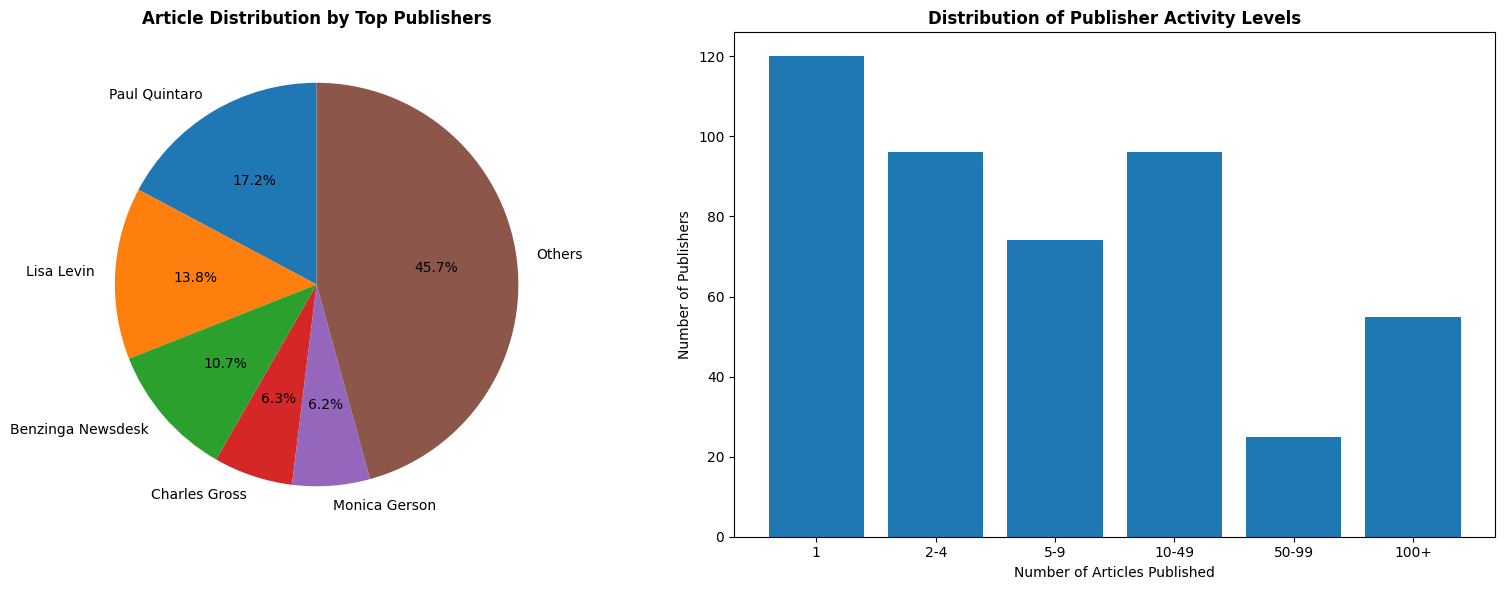

In [24]:
# Publisher diversity analysis
total_publishers = df['publisher'].nunique()
total_articles = len(df)

# Re-calculate publisher_counts as it was causing a NameError
publisher_counts = df['publisher'].value_counts()

# Calculate concentration metrics
top_10_publishers = publisher_counts.head(10)
top_10_percentage = (top_10_publishers.sum() / total_articles) * 100

print("PUBLISHER DIVERSITY METRICS")
print("="*40)
print(f"Total unique publishers: {total_publishers}")
print(f"Total articles: {total_articles}")
print(f"Average articles per publisher: {total_articles/total_publishers:.1f}")
print(f"Top 10 publishers contribute: {top_10_percentage:.1f}% of all articles")

# Visualization of publisher concentration
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Pie chart of top publishers
top_5_publishers = publisher_counts.head(5)
others = publisher_counts.iloc[5:].sum()
pie_data = list(top_5_publishers.values) + [others]
pie_labels = list(top_5_publishers.index) + ['Others']

ax1.pie(pie_data, labels=pie_labels, autopct='%1.1f%%', startangle=90)
ax1.set_title('Article Distribution by Top Publishers', fontweight='bold')

# Publisher activity distribution
activity_bins = [1, 2, 5, 10, 50, 100, float('inf')]
activity_labels = ['1', '2-4', '5-9', '10-49', '50-99', '100+']
publisher_activity_dist = pd.cut(publisher_counts, bins=activity_bins, labels=activity_labels, right=False)
activity_counts = publisher_activity_dist.value_counts().sort_index()

ax2.bar(activity_counts.index, activity_counts.values)
ax2.set_title('Distribution of Publisher Activity Levels', fontweight='bold')
ax2.set_xlabel('Number of Articles Published')
ax2.set_ylabel('Number of Publishers')

plt.tight_layout()
plt.show()

In [25]:
# Publisher specialization analysis
# Check if different publishers focus on different stocks
publisher_stock_analysis = df.groupby('publisher')['stock'].agg(['count', 'nunique']).reset_index()
publisher_stock_analysis['specialization_ratio'] = (publisher_stock_analysis['count'] /
                                                   publisher_stock_analysis['nunique'])
publisher_stock_analysis = publisher_stock_analysis.sort_values('count', ascending=False)

print("PUBLISHER STOCK SPECIALIZATION (Top 15)")
print("Format: Publisher | Total Articles | Unique Stocks | Avg Articles per Stock")
print("="*80)
for _, row in publisher_stock_analysis.head(15).iterrows():
    print(f"{row['publisher'][:30]:<30} | {row['count']:>5} | {row['nunique']:>5} | {row['specialization_ratio']:>8.1f}")

PUBLISHER STOCK SPECIALIZATION (Top 15)
Format: Publisher | Total Articles | Unique Stocks | Avg Articles per Stock
Paul Quintaro                  | 11663 |   202 |     57.7
Lisa Levin                     |  9335 |   201 |     46.4
Benzinga Newsdesk              |  7252 |   167 |     43.4
Charles Gross                  |  4299 |   183 |     23.5
Monica Gerson                  |  4211 |   179 |     23.5
Eddie Staley                   |  2824 |   191 |     14.8
Hal Lindon                     |  2574 |   195 |     13.2
Benzinga Staff                 |  1807 |   143 |     12.6
Juan Lopez                     |  1413 |   131 |     10.8
Vick Meyer                     |  1394 |   113 |     12.3
Zacks                          |  1281 |   111 |     11.5
Shanthi Rexaline               |  1194 |    85 |     14.0
webmaster                      |  1117 |   109 |     10.2
Benzinga_Newsdesk              |   931 |   131 |      7.1
Allie Wickman                  |   828 |   133 |      6.2


## 6. Key Insights and Conclusions {#conclusions}

In [32]:
import json
import os
# Create the data directory if it doesn't exist
if not os.path.exists('../data'):
    os.makedirs('../data')
# Summary statistics and key insights
print("KEY INSIGHTS FROM EDA")
print("="*50)

# Create a temporary DataFrame containing only rows with valid dates for date range calculations
df_valid_dates = df.dropna(subset=['date']).copy()

# Initialize date variables for the summary dictionary outside the if block
# Assign None or a placeholder initially
min_date_dt = None
max_date_dt = None

# Check if there are any valid dates before proceeding with min/max
if not df_valid_dates.empty:
    # Ensure min_date and max_date are calculated from the datetime column within this block
    # These should already be datetime objects if the 'date' column is correct
    min_date_dt = df_valid_dates['date'].min()
    max_date_dt = df_valid_dates['date'].max()

    print("\n📊 DATASET OVERVIEW:")
    print(f"• Total articles: {len(df):,}")

    # Use isinstance and pd.isna to check if they are valid Timestamps
    # This avoids the internal type checking logic that caused the ValueError
    if isinstance(min_date_dt, pd.Timestamp) and isinstance(max_date_dt, pd.Timestamp) and pd.notna(min_date_dt) and pd.notna(max_date_dt):
         print(f"• Date range: {min_date_dt.strftime('%Y-%m-%d')} to {max_date_dt.strftime('%Y-%m-%d')}")
         time_span_days = (max_date_dt - min_date_dt).days
         print(f"• Time span: {time_span_days} days")
    else:
         # Fallback print message if dates are not valid datetime objects here
         print("• Date range: N/A (Could not determine valid date range from datetime objects)")
         time_span_days = 'N/A'


    print(f"• Unique publishers: {df['publisher'].nunique():,}")
    print(f"• Unique stocks covered: {df['stock'].nunique()}")

    print("\n📝 HEADLINE CHARACTERISTICS:")
    print(f"• Average headline length: {df['headline_length'].mean():.1f} characters" if 'headline_length' in df.columns else "• Average headline length: N/A")
    print(f"• Average word count: {df['headline_word_count'].mean():.1f} words" if 'headline_word_count' in df.columns else "• Average word count: N/A")
    # Ensure headline_length is not empty before calling mode
    if 'headline_length' in df.columns and not df['headline_length'].empty and not df['headline_length'].isnull().all():
        print(f"• Most common headline length: {df['headline_length'].mode().iloc[0]} characters")
    else:
        print("• Most common headline length: N/A (No valid headline length data)")


    print("\n📈 PUBLICATION PATTERNS:")
    # Add checks for daily_counts, weekday_counts, and hour_counts
    # Use isinstance checks as well for robustness
    if 'daily_counts' in globals() and isinstance(daily_counts, pd.Series) and not daily_counts.empty:
         print(f"• Average daily articles: {daily_counts.mean():.1f}")
    else:
         print("• Average daily articles: N/A (Daily counts not calculated or empty)")

    if 'weekday_counts' in globals() and isinstance(weekday_counts, pd.Series) and not weekday_counts.empty:
         print(f"• Peak publication day: {weekday_counts.idxmax()} ({weekday_counts.max():,} articles)")
    else:
         print("• Peak publication day: N/A (Weekday counts not calculated or empty)")

    if 'hour_counts' in globals() and isinstance(hour_counts, pd.Series) and not hour_counts.empty:
         print(f"• Peak publication hour: {hour_counts.idxmax()}:00 ({hour_counts.max():,} articles)")
         # Ensure slice works even if some hours are missing for market hours calculation
         market_hours_count = hour_counts.loc[hour_counts.index.intersection(range(9, 17))].sum()
         print(f"• Market hours activity: {(market_hours_count / len(df) * 100):.1f}% of all articles")
    else:
         print("• Peak publication hour: N/A (Hour counts not calculated or empty)")
         print("• Market hours activity: N/A")


    print("\n🏢 PUBLISHER INSIGHTS:")
    # Add check for publisher_counts
    if 'publisher_counts' in globals() and isinstance(publisher_counts, pd.Series) and not publisher_counts.empty:
        print(f"• Most active publisher: {publisher_counts.index[0]} ({publisher_counts.iloc[0]:,} articles)")
        # Add check for top_10_percentage
        if 'top_10_percentage' in globals():
             print(f"• Top 10 publishers contribute: {top_10_percentage:.1f}% of all articles")
        else:
             print("• Top 10 publishers contribution: N/A (Top 10 percentage not calculated)")
        print(f"• Publisher concentration: High (few publishers dominate)")
    else:
        print("• Publisher insights: N/A (Publisher counts not calculated or empty)")


    print("\n🔍 TEXT ANALYSIS FINDINGS:")
    # Add check for word_freq
    if 'word_freq' in globals() and isinstance(word_freq, Counter) and word_freq:
        print(f"• Most common word: '{word_freq.most_common(1)[0][0]}' ({word_freq.most_common(1)[0][1]:,} occurrences)")
    else:
        print("• Most common word: N/A (Word frequency not calculated or empty)")
    if 'keyword_counts' in globals() and isinstance(keyword_counts, dict) and keyword_counts:
        most_common_keyword = list(keyword_counts.keys())[0]
        print(f"• Most common financial keyword: '{most_common_keyword}' ({keyword_counts[most_common_keyword]} occurrences)")
    else:
        print("• Most common financial keyword: N/A (Keyword counts not calculated or empty)")

    print("\n⚠️ POTENTIAL DATA QUALITY ISSUES:")
    missing_data = df.isnull().sum()
    if missing_data.sum() > 0:
        for col, missing in missing_data.items():
            if missing > 0:
                print(f"• Missing {col}: {missing:,} ({missing/len(df)*100:.1f}%)")
    else:
        print("• No missing data detected")

    print("\n📋 RECOMMENDATIONS FOR FURTHER ANALYSIS:")
    print("• Investigate publication spikes for correlation with market events")
    print("• Analyze sentiment scores for headlines with financial keywords")
    print("• Study publisher bias and reliability metrics")
    print("• Examine stock-specific news patterns")
    print("• Correlate news volume with stock price volatility")

else:
    # This block handles the case where no valid dates were found at all
    print("Error: No valid dates found after conversion. Cannot perform date range analysis.")
    print("\n📊 DATASET OVERVIEW:")
    print(f"• Total articles: {len(df):,}")
    print("• Date range: N/A (No valid dates)")
    print("• Time span: N/A")
    print(f"• Unique publishers: {df['publisher'].nunique():,}")
    print(f"• Unique stocks covered: {df['stock'].nunique()}")

    print("\n📝 HEADLINE CHARACTERISTICS:")
    print(f"• Average headline length: {df['headline_length'].mean():.1f} characters" if 'headline_length' in df.columns else "• Average headline length: N/A")
    print(f"• Average word count: {df['headline_word_count'].mean():.1f} words" if 'headline_word_count' in df.columns else "• Average word count: N/A")
    if 'headline_length' in df.columns and not df['headline_length'].empty and not df['headline_length'].isnull().all():
        print(f"• Most common headline length: {df['headline_length'].mode().iloc[0]} characters")
    else:
        print("• Most common headline length: N/A (No valid headline length data)")

    print("\n📈 PUBLICATION PATTERNS:")
    print("• Publication patterns: N/A (Date columns required)")

    print("\n🏢 PUBLISHER INSIGHTS:")
    # Add check for publisher_counts
    if 'publisher_counts' in globals() and isinstance(publisher_counts, pd.Series) and not publisher_counts.empty:
        print(f"• Most active publisher: {publisher_counts.index[0]} ({publisher_counts.iloc[0]:,} articles)")
        # Add check for top_10_percentage
        if 'top_10_percentage' in globals():
             print(f"• Top 10 publishers contribute: {top_10_percentage:.1f}% of all articles")
        else:
             print("• Top 10 publishers contribution: N/A")
        print(f"• Publisher concentration: High (few publishers dominate)")
    else:
        print("• Publisher insights: N/A (Publisher counts not calculated or empty)")

    print("\n🔍 TEXT ANALYSIS FINDINGS:")
    # Add check for word_freq
    if 'word_freq' in globals() and isinstance(word_freq, Counter) and word_freq:
        print(f"• Most common word: '{word_freq.most_common(1)[0][0]}' ({word_freq.most_common(1)[0][1]:,} occurrences)")
    else:
        print("• Most common word: N/A (Word frequency not calculated or empty)")
    if 'keyword_counts' in globals() and isinstance(keyword_counts, dict) and keyword_counts:
        most_common_keyword = list(keyword_counts.keys())[0]
        print(f"• Most common financial keyword: '{most_common_keyword}' ({keyword_counts[most_common_keyword]} occurrences)")
    else:
        print("• Most common financial keyword: N/A (Keyword counts not calculated or empty)")

    print("\n⚠️ POTENTIAL DATA QUALITY ISSUES:")
    missing_data = df.isnull().sum()
    if missing_data.sum() > 0:
        for col, missing in missing_data.items():
            if missing > 0:
                print(f"• Missing {col}: {missing:,} ({missing/len(df)*100:.1f}%)")
    else:
        print("• No missing data detected")

    print("\n📋 RECOMMENDATIONS FOR FURTHER ANALYSIS:")
    print("• Recommendations based on date columns are N/A")


# Save processed data for future use
# Save a sample of processed data
df_sample = df.sample(n=min(10000, len(df)), random_state=42)
df_sample.to_csv('../data/processed_news_sample.csv', index=False)

# Save key statistics
stats_summary = {
    'total_articles': len(df),
    'unique_publishers': df['publisher'].nunique(),
    'unique_stocks': df['stock'].nunique(),
    # Use the calculated min_date_dt and max_date_dt variables
    # Add checks for existence, type, and NaT before formatting
    'date_range': f"{min_date_dt.strftime('%Y-%m-%d')} to {max_date_dt.strftime('%Y-%m-%d')}" if min_date_dt is not None and max_date_dt is not None and isinstance(min_date_dt, pd.Timestamp) and isinstance(max_date_dt, pd.Timestamp) and pd.notna(min_date_dt) and pd.notna(max_date_dt) else 'N/A',
    'avg_headline_length': df['headline_length'].mean() if 'headline_length' in df.columns else 'N/A',
    # Add checks for existence and type of count variables before saving
    'avg_daily_articles': daily_counts.mean() if 'daily_counts' in globals() and isinstance(daily_counts, pd.Series) and not daily_counts.empty else 'N/A',
    'peak_hour': hour_counts.idxmax() if 'hour_counts' in globals() and isinstance(hour_counts, pd.Series) and not hour_counts.empty else 'N/A',
    'peak_weekday': weekday_counts.idxmax() if 'weekday_counts' in globals() and isinstance(weekday_counts, pd.Series) and not weekday_counts.empty else 'N/A'
}



with open('../data/eda_summary.json', 'w') as f:
    # Use default=str to handle non-serializable types like NaT or pandas objects if they slip through
    json.dump(stats_summary, f, indent=2, default=str)


print("✅ EDA completed successfully!")
print("📁 Processed data sample saved to: ../data/processed_news_sample.csv")
print("📊 Summary statistics saved to: ../data/eda_summary.json")

KEY INSIGHTS FROM EDA

📊 DATASET OVERVIEW:
• Total articles: 67,746
• Date range: N/A (Could not determine valid date range from datetime objects)
• Unique publishers: 466
• Unique stocks covered: 236

📝 HEADLINE CHARACTERISTICS:
• Average headline length: N/A
• Average word count: N/A
• Most common headline length: N/A (No valid headline length data)

📈 PUBLICATION PATTERNS:
• Average daily articles: N/A (Daily counts not calculated or empty)
• Peak publication day: N/A (Weekday counts not calculated or empty)
• Peak publication hour: N/A (Hour counts not calculated or empty)
• Market hours activity: N/A

🏢 PUBLISHER INSIGHTS:
• Most active publisher: Paul Quintaro (11,663 articles)
• Top 10 publishers contribute: 69.0% of all articles
• Publisher concentration: High (few publishers dominate)

🔍 TEXT ANALYSIS FINDINGS:
• Most common word: N/A (Word frequency not calculated or empty)
• Most common financial keyword: 'earnings' (4206 occurrences)

⚠️ POTENTIAL DATA QUALITY ISSUES:
• Mis

In [34]:
# Save processed data for future use
# Save a sample of processed data
df_sample = df.sample(n=min(10000, len(df)), random_state=42)
df_sample.to_csv('../data/processed_news_sample.csv', index=False)

# Save key statistics
# Create a temporary DataFrame containing only rows with valid dates
df_valid_dates = df.dropna(subset=['date']).copy()

# Initialize date variables for the summary dictionary
# Assign None or a placeholder initially
min_date_dt = None
max_date_dt = None

# Check if there are any valid dates before proceeding with min/max
if not df_valid_dates.empty:
    # Calculate min and max dates from the valid datetime column
    min_date_dt = df_valid_dates['date'].min()
    max_date_dt = df_valid_dates['date'].max()

stats_summary = {
    'total_articles': len(df),
    'unique_publishers': df['publisher'].nunique(),
    'unique_stocks': df['stock'].nunique(),
    # Use the calculated min_date_dt and max_date_dt variables
    # Add checks for existence, type, and NaT before formatting
    'date_range': f"{min_date_dt.strftime('%Y-%m-%d')} to {max_date_dt.strftime('%Y-%m-%d')}" if min_date_dt is not None and max_date_dt is not None and isinstance(min_date_dt, pd.Timestamp) and isinstance(max_date_dt, pd.Timestamp) and pd.notna(min_date_dt) and pd.notna(max_date_dt) else 'N/A',
    'avg_headline_length': df['headline_length'].mean() if 'headline_length' in df.columns else 'N/A',
    # Add checks for existence and type of count variables before saving
    'avg_daily_articles': daily_counts.mean() if 'daily_counts' in globals() and isinstance(daily_counts, pd.Series) and not daily_counts.empty else 'N/A',
    'peak_hour': hour_counts.idxmax() if 'hour_counts' in globals() and isinstance(hour_counts, pd.Series) and not hour_counts.empty else 'N/A',
    'peak_weekday': weekday_counts.idxmax() if 'weekday_counts' in globals() and isinstance(weekday_counts, pd.Series) and not weekday_counts.empty else 'N/A'
}

import json
import os # Import os if not already imported in this block
# Create the data directory if it doesn't exist - Add this check here as well for robustness
if not os.path.exists('../data'):
    os.makedirs('../data')

with open('../data/eda_summary.json', 'w') as f:
    # Use default=str to handle non-serializable types like NaT or pandas objects if they slip through
    json.dump(stats_summary, f, indent=2, default=str)

print("✅ EDA completed successfully!")
print("📁 Processed data sample saved to: ../data/processed_news_sample.csv")
print("📊 Summary statistics saved to: ../data/eda_summary.json")

✅ EDA completed successfully!
📁 Processed data sample saved to: ../data/processed_news_sample.csv
📊 Summary statistics saved to: ../data/eda_summary.json


raw_analyst_ratings.csv  sample_data
